In [44]:
import torch as t
import numpy as np 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
import random
from Functions import *

j = complex(0, 1)

0.39038390383903837 3.280753268483129


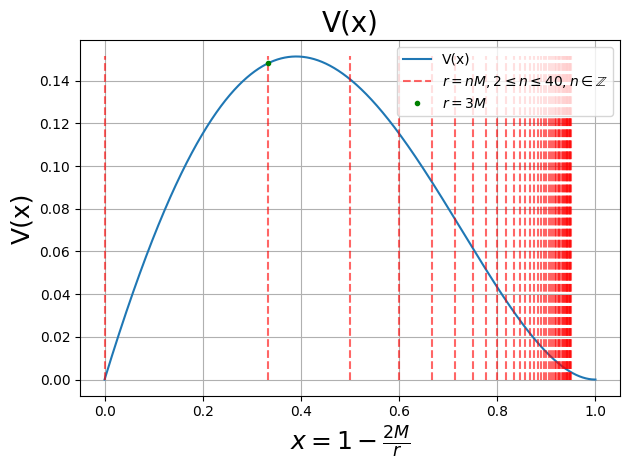

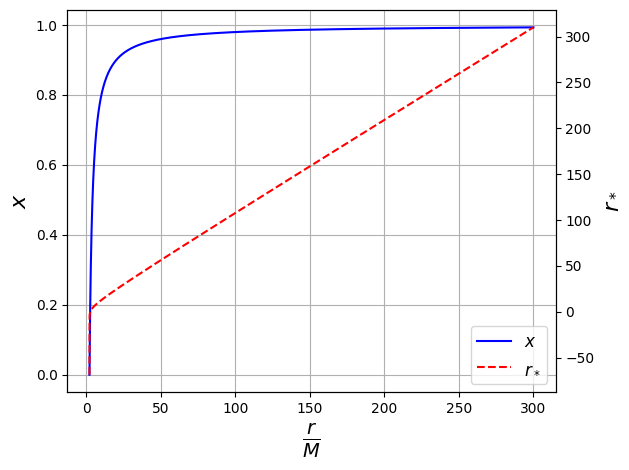

In [45]:
M = 1
l = 2#
eps = 1e-15
x = np.linspace(0, 1, 100000)
r = np.linspace(2 + eps, 300, 100000)
x_coord = r_to_x(r, M)
rstar_coord = r_to_rstar(r, M)

def Vx(x, M, l):
    return x*(1-x)**2/(4*M**2)*(l*(l+1) - 3*(1-x))

V_PINN = Vx(x, M, l)

peak_idx = np.argmax(V_PINN)
print(x[peak_idx], x_to_r(x[peak_idx], M))

light_ring = 1-2*M/3*M

radii = np.array(range(39)) + 2

# xs = []
# for r in radii:
#     xs.append(r_to_x(r, M))

plt.figure()
plt.plot(x, V_PINN, label = r'V(x)')
plt.vlines(1 - 2*M/radii, [0]*len(radii), [np.max(V_PINN)]*len(radii), 'r', 'dashed', alpha = 0.6, label = r'$ r = nM, 2 \leq n \leq 40, n \in \mathbb{Z}$')
plt.plot(light_ring, Vx(light_ring, M, l), '.', color = 'green', label = r'$r = 3M$')
plt.xlabel(r'$x = 1 - \frac{2M}{r}$', fontsize = 18)
plt.ylabel('V(x)', fontsize = 18)
plt.title('V(x)', fontsize = 20)
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
line1 = ax1.plot(r, x_coord, color = 'blue', label=r'$x$')
ax1.set_xlabel(r'$\frac{r}{M}$', fontsize=20)
ax1.set_ylabel(r'$x$', fontsize=16)
ax1.tick_params(axis = 'y')
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(r, rstar_coord, color = 'red', linestyle='--', label=r'$r_*$')
ax2.set_ylabel(r'$r_*$', fontsize=16)
ax2.tick_params(axis='y')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize = 'large', loc='lower right')
fig.tight_layout()  
plt.show()


c:\Users\danie\Documents\MSci-Project\MSci-Project\Functions.py:21: RuntimeWarning: divide by zero encountered in divide
  return 2*M/(1-x)


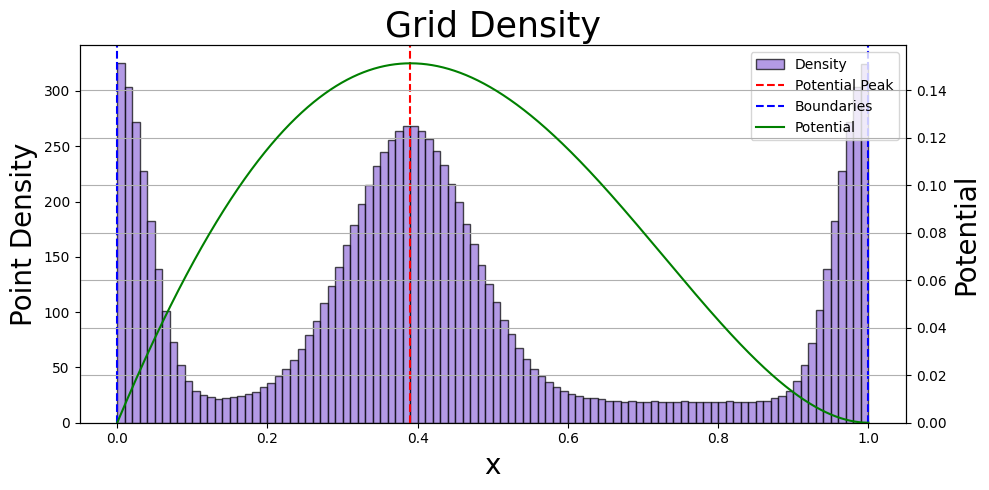

In [46]:
x_test = np.linspace(0, 1, 1000)

def dense_grid(n_points, x_peak, peak_width, peak_intensity, bound_width, bound_intensity):

    ref_x = np.linspace(0, 1, 25000)
    weights = 1.0 + peak_intensity*np.exp(-(ref_x - x_peak)**2/(2*peak_width**2)) 
    weights += bound_intensity*np.exp(-(ref_x - 1)**2/(2*bound_width**2)) 
    weights += bound_intensity*np.exp(-(ref_x - 0)**2/(2*bound_width**2)) 
    
    cdf = np.cumsum(weights)
    cdf /= cdf[-1] 

    uniform_steps = np.linspace(0, 1, n_points)
    clustered_x = np.interp(uniform_steps, cdf, ref_x)
    
    return clustered_x

M = 1.0
l = 2
x_peak = Vpm_peak(M = 1, l = 2, parity = "axial", coord = 'x')

N = 10000

x_grid = dense_grid(N, x_peak, peak_intensity = 13, peak_width = 0.08, 
                    bound_intensity = 16, bound_width = 0.04)
V_PINN = Vpm(x_to_r(x_grid, M), M, l, "axial")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.hist(x_grid, bins=100, color = 'mediumpurple', alpha = 0.7, edgecolor='black', label = 'Density')
ax1.set_xlabel("x", fontsize = 20)
ax1.set_ylabel("Point Density", fontsize = 20)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(x_grid, V_PINN, color='green', label='Potential')
ax2.set_ylabel("Potential", fontsize = 20)
ax2.tick_params(axis='y')

ax1.axvline(x_peak, color='red', linestyle='--', label='Potential Peak')
ax1.axvline(0, color='blue', linestyle='--', label='Boundaries')
ax1.axvline(1, color='blue', linestyle='--')

ax1.set_ylim(bottom = 0)
ax2.set_ylim(bottom = 0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Grid Density", fontsize = 25)
plt.tight_layout()
plt.grid()
plt.show()

# plt.figure()
# plt.scatter(x_test, transformed_x)
# plt.plot(x_test, np.ones_like(x_test), '.', label = 'Regular')
# plt.plot(transformed_x, np.zeros_like(x_test), '.', label = 'Transformed')
# plt.vlines(0.39, 0, 1, label = 'x = x_peak')
# plt.tight_layout()
# plt.legend()
# plt.show()

In [47]:
#PINN architecture
class Model(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_hidden_layers=2):
        super().__init__() 
        self.input_layer = nn.Linear(in_channels, hidden_channels)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_channels, hidden_channels) for _ in range(num_hidden_layers)]) 
        self.output_layer = nn.Linear(hidden_channels, out_channels) 

    def forward(self, x: t.tensor):
        #x is a tensor with shape [batch_size, in_channels]
        x = F.tanh(self.input_layer(x)) 
        #x leaves as tensor with shape [batch_size, hidden_channels]
        for hidden_layer in self.hidden_layers:
            x = F.tanh(hidden_layer(x))
        #x leaves as tensor with shape [batch_size, output_channels]
        x = self.output_layer(x) 
        return x 

#Set up
DTYPE = t.float32
NP_DTYPE = np.float32 if DTYPE == t.float32 else np.float64
mass = 1
mode = 2
x_horizon = t.tensor(0., requires_grad = True, dtype = DTYPE).view(-1, 1)
x_infinity = t.tensor(1., requires_grad = True, dtype = DTYPE).view(-1, 1)
x_tensor = t.tensor(x_grid, requires_grad = True, dtype = DTYPE).view(-1, 1)

#Define functions
def grads(y, x):
        dy = t.autograd.grad(y, x, t.ones_like(y), create_graph = True)[0]
        d2y = t.autograd.grad(dy, x, t.ones_like(dy), create_graph = True)[0]
        return dy, d2y

def A(x):
    A = x*(1 - x)**2
    return A

def B(x, rho_re, rho_im, M):
        B_re = (8*M*rho_re + 3)*x**2 - 4*(4*M*rho_re + 1)*x + 4*M*rho_re + 1
        B_im = (8*M*rho_im)*x**2 - 4*(4*M*rho_im)*x + 4*M*rho_im
        return B_re, B_im

def C(x, rho_re, rho_im, M, l):
    C_re = 3*(1 - x) - l*(l + 1) + 4*M**2*(rho_re**2 - rho_im**2)*(x - 4) + 2*M*rho_re*(2*x - 3)
    C_im = 4*M**2*(2*rho_im*rho_re)*(x - 4) + 2*M*rho_im*(2*x - 3)
    return C_re, C_im


learning_rate = 1e-2
model = Model(1, 2, 64).to(dtype = DTYPE)
rho_real = nn.Parameter(t.tensor([-0.08], requires_grad = True, dtype = DTYPE))
rho_imag = nn.Parameter(t.tensor([-0.37], requires_grad = True, dtype = DTYPE))
optimiser = optim.Adam([
    {'params': model.parameters(), 'lr': 1e-3},
    {'params': [rho_real, rho_imag], 'lr': 1e-2}])

#Loss functionality
loss_h_weight = 1.0
loss_h = []
loss_nontrivial_weight = 1.0
loss_nt = []
loss_inf_weight = 1.0
loss_inf = []
loss_ODE_weight = 1.0
loss_ODE = []
loss_weights = [loss_h_weight, loss_nontrivial_weight, loss_inf_weight, loss_ODE_weight]


number_iterations = 5000
loss_total = []
for epoch in range(number_iterations):
    optimiser.zero_grad()
    # if epoch <= 1000:
    #     loss_weights[1] = 100.0
    # else:
    #     loss_weights[1] = 1.0

    #Horizon BC
    w_h = model(x_horizon)
    w_h_re, w_h_im = w_h[:, 0:1], w_h[:, 1:2]
    dw_h_re, d2w_h_re = grads(w_h_re, x_horizon)
    dw_h_im, d2w_h_im = grads(w_h_im, x_horizon)

    B_h_re, B_h_im = B(x_horizon, rho_real, rho_imag, mass)
    C_h_re, C_h_im = C(x_horizon, rho_real, rho_imag, mass, mode)

    loss_horizon_re = (B_h_re*dw_h_re - B_h_im*dw_h_im +
                        C_h_re*w_h_re - C_h_im*w_h_im)
    loss_horizon_im = (B_h_im*dw_h_re + B_h_re*dw_h_im + 
                    C_h_im*w_h_re + C_h_re*w_h_im)
    loss_horizon = loss_horizon_re**2 + loss_horizon_im**2
    loss_nontrivial = (1.0 - w_h_re)**2 + (0.0 - w_h_im)**2

    #Infinity BC
    w_inf = model(x_infinity)
    w_inf_re, w_inf_im = w_inf[:, 0:1], w_inf[:, 1:2]
    dw_inf_re, d2w_inf_re = grads(w_inf_re, x_infinity)
    dw_inf_im, d2w_inf_im = grads(w_inf_im, x_infinity)

    B_inf_re, B_inf_im = B(x_infinity, rho_real, rho_imag, mass)
    C_inf_re, C_inf_im = C(x_infinity, rho_real, rho_imag, mass, mode)

    loss_infinity_re = B_inf_re*dw_inf_re - B_inf_im*dw_inf_im + C_inf_re*w_inf_re - C_inf_im*w_inf_im
    loss_infinity_im = B_inf_im*dw_inf_re + B_inf_re*dw_inf_im + C_inf_im*w_inf_re + C_inf_re*w_inf_im
    loss_infinity = loss_infinity_re**2 + loss_infinity_im**2

    #Change to sum of square of components

    #Physics loss
    w_nn = model(x_tensor)
    w_nn_re, w_nn_im = w_nn[:, 0:1], w_nn[:, 1:2]
    dw_nn_re, d2w_nn_re = grads(w_nn_re, x_tensor)
    dw_nn_im, d2w_nn_im = grads(w_nn_im, x_tensor)

    A_ = A(x_tensor)
    B_re, B_im = B(x_tensor, rho_real, rho_imag, mass)
    C_re, C_im = C(x_tensor, rho_real, rho_imag, mass, mode)

    loss_ode_re = (A_*d2w_nn_re + B_re*dw_nn_re - B_im*dw_nn_im + C_re*w_nn_re - C_im*w_nn_im)
    loss_ode_im = (A_*d2w_nn_im + B_im*dw_nn_re + B_re*dw_nn_im + C_im*w_nn_re + C_re*w_nn_im)
    loss_ode = t.mean(loss_ode_re**2 + loss_ode_im**2)


    loss = (loss_weights[0]*t.mean(loss_horizon) + loss_weights[1]*t.mean(loss_nontrivial) + 
            loss_weights[2]*t.mean(loss_infinity) + loss_weights[3]*loss_ode)

    loss.backward()
    optimiser.step()

    with t.no_grad():
        loss_h.append(loss_horizon.item())
        loss_nt.append(loss_nontrivial.item())
        loss_inf.append(loss_infinity.item())
        loss_ODE.append(loss_ode.item())
        loss_total.append(loss.item())
    
    if (epoch + 1) % 500 == 0 or epoch == 0:
        print(f"""Epoch: {epoch + 1} / {number_iterations}. Total scaled loss: {loss.item():.4e}, 
                    ODE(0) loss: {loss_horizon.item():.4e}, 
                    ODE(1) loss: {loss_infinity.item():.4e}, 
                    Non-trivial solution loss: {loss_nontrivial.item():.4e},
                    Physics loss: {loss_ode.item():.4e},
                    Current value of rho: {rho_real.item():.5f} + {rho_imag.item():.5f}i""")
        print("-"*30)

losses = np.array([loss_h, loss_nt, loss_inf, loss_ODE, loss_total])


Epoch: 1 / 5000. Total scaled loss: 2.2100e+00, 
                    ODE(0) loss: 5.3684e-02, 
                    ODE(1) loss: 6.2145e-01, 
                    Non-trivial solution loss: 1.3227e+00,
                    Physics loss: 2.1223e-01,
                    Current value of rho: -0.09000 + -0.38000i
------------------------------
Epoch: 500 / 5000. Total scaled loss: 5.2915e-03, 
                    ODE(0) loss: 3.6523e-04, 
                    ODE(1) loss: 3.1821e-03, 
                    Non-trivial solution loss: 8.8260e-05,
                    Physics loss: 1.6560e-03,
                    Current value of rho: -0.14788 + -0.48875i
------------------------------
Epoch: 1000 / 5000. Total scaled loss: 8.0250e-04, 
                    ODE(0) loss: 1.1041e-05, 
                    ODE(1) loss: 3.7196e-05, 
                    Non-trivial solution loss: 1.3834e-06,
                    Physics loss: 7.5288e-04,
                    Current value of rho: -0.15007 + -0.48811i
------

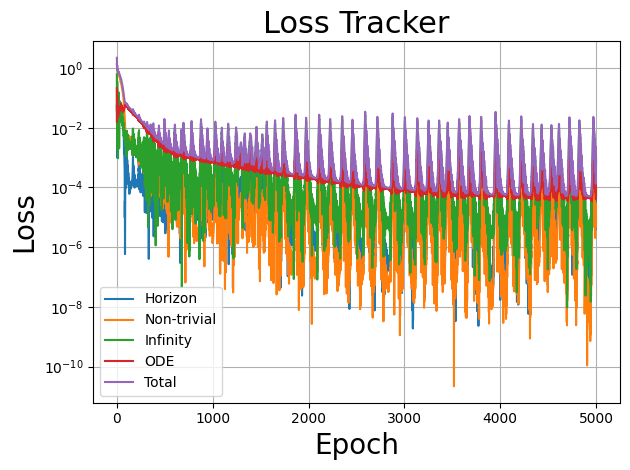

In [53]:
labels = ['Horizon', 'Non-trivial', 'Infinity', 'ODE', 'Total']

plt.figure()
for i, l in enumerate(losses):
    plt.plot(range(number_iterations), l, label = labels[i])
plt.yscale('log')
plt.xlabel('Epoch', fontsize = 20)
plt.ylabel('Loss', fontsize = 20)
plt.title('Loss Tracker', fontsize = 22)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#NOW PLOT ODE RESIDUAL AND RHO WALK AROUND COMPLEX PLANE


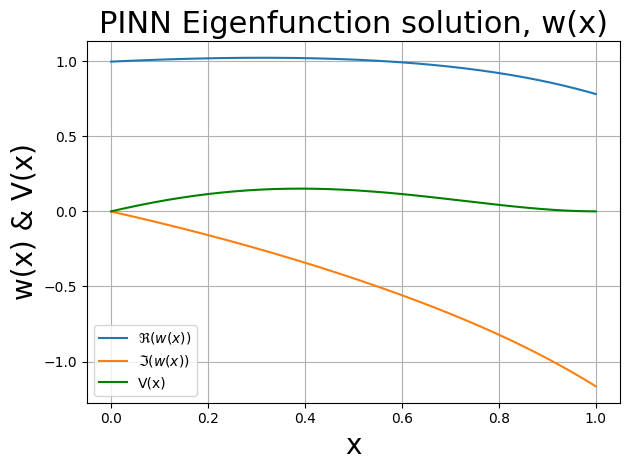

C:\Users\danie\AppData\Local\Temp\ipykernel_21416\3871361138.py:18: RuntimeWarning: divide by zero encountered in divide
  Psi = np.exp(-2*mass*rho/(1 - x_grid))*(1 - x_grid)**(2*mass*rho)*x_grid**(2*mass*rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])
C:\Users\danie\AppData\Local\Temp\ipykernel_21416\3871361138.py:18: RuntimeWarning: overflow encountered in exp
  Psi = np.exp(-2*mass*rho/(1 - x_grid))*(1 - x_grid)**(2*mass*rho)*x_grid**(2*mass*rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])
C:\Users\danie\AppData\Local\Temp\ipykernel_21416\3871361138.py:18: RuntimeWarning: invalid value encountered in exp
  Psi = np.exp(-2*mass*rho/(1 - x_grid))*(1 - x_grid)**(2*mass*rho)*x_grid**(2*mass*rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])
C:\Users\danie\AppData\Local\Temp\ipykernel_21416\3871361138.py:18: RuntimeWarning: invalid value encountered in power
  Psi = np.exp(-2*mass*rho/(1 - x_grid))*(1 - x_grid)**(2*mass*rho)*x_grid**(2*mass*rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])
C:\Users\da

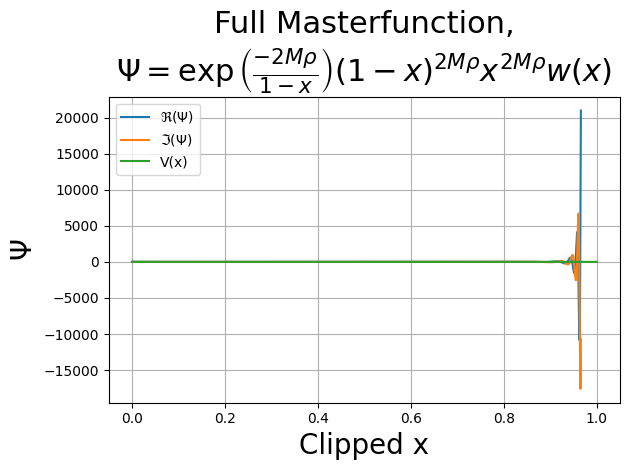

In [51]:
cut = 1000
with t.no_grad():
    w_out = model(x_tensor).numpy()
    plt.figure()
    plt.plot(x_grid, w_out[:, 0], label = r'$\Re(w(x))$')
    plt.plot(x_grid, w_out[:, 1], label = r'$\Im(w(x))$')
    plt.plot(x_grid, V_PINN, color = 'green', label = 'V(x)')
    plt.xlabel('x', fontsize = 20)
    plt.ylabel('w(x) & V(x)', fontsize = 20)
    plt.title('PINN Eigenfunction solution, w(x)', fontsize = 22)
    plt.tight_layout()
    plt.grid()
    plt.legend()
    plt.show()

    rho = complex(rho_real.item(), rho_imag.item())
    omega = complex(0, 1)*rho
    Psi = np.exp(-2*mass*rho/(1 - x_grid))*(1 - x_grid)**(2*mass*rho)*x_grid**(2*mass*rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])

    plt.figure()
    plt.plot(x_grid[:len(x_grid) - cut], Psi.real[:len(x_grid) - cut], label = r'$\Re(\Psi)$')
    plt.plot(x_grid[:len(x_grid) - cut], Psi.imag[:len(x_grid) - cut], label = r'$\Im(\Psi)$')
    plt.plot(x_grid, V_PINN, label = 'V(x)')
    plt.xlabel('Clipped x', fontsize = 20)
    plt.ylabel(r'$\Psi$', fontsize = 20)
    plt.title('Full Masterfunction,'
        '\n'
        r'$\Psi = \exp{\left(\frac{-2M \rho}{1 - x}\right)} (1 - x)^{2M \rho} x^{2M \rho} w(x)$', fontsize = 22)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()
    